# _Segmentaçõ, Processamento do Dataset...._

# ⬇️ | Imports

In [31]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm import tqdm
import seaborn as sns

from skimage.feature import graycomatrix, graycoprops
from skimage.measure import regionprops, label

# ⬇️ | Dataset

In [32]:
## dataset disponivel no Kaggle
## Kaggle - https://www.kaggle.com/datasets/sriramr/fruits-fresh-and-rotten-for-classification/data


DATASET_PATH = Path("dataset")

TRAIN_PATH = DATASET_PATH / "train"

# 🥸 | Características


## 🧩 | Segmentação - HSV e Morphology


In [33]:
def segmentar_hsv(img):

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    lower = np.array([0, 40, 20])

    upper = np.array([179, 255, 255])

    mascara = cv2.inRange(hsv, lower, upper)

    kernel = np.ones((5,5), np.uint8)

    mascara = cv2.morphologyEx(mascara, cv2.MORPH_OPEN, kernel)

    mascara = cv2.morphologyEx(mascara, cv2.MORPH_CLOSE, kernel)

    return mascara

## 🎲 | Features

In [34]:
def extrair_shape_features(mask):

    rotulos = label(mask)

    props = regionprops(rotulos)

    if len(props) == 0:

        return [0,0,0,0,0,0]

    obj = max(props,key=lambda x: x.area)

    area = obj.area

    perimeter = obj.perimeter

    eccentricity = obj.eccentricity

    solidity = obj.solidity

    extent = obj.extent

    circularity = (4*np.pi*area) / (perimeter**2 + 1e-8)

    return [
        area,
        perimeter,
        eccentricity,
        solidity,
        extent,
        circularity
    ]

## 😶‍🌫️ | Hu moments

In [35]:
def extrair_hu(mask):

    momentos = cv2.moments(mask)

    hu = cv2.HuMoments(momentos)

    hu = -np.sign(hu) * np.log10(np.abs(hu) + 1e-10)

    return hu.flatten().tolist()

## 🎨 | Color Features

In [36]:
def extrair_cor(img, mask):
    pixels_bgr = img[mask > 0]
    if len(pixels_bgr) == 0:
        return [0,0,0, 0,0,0] 
        
    media_bgr = np.mean(pixels_bgr, axis=0)

    
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    pixels_hsv = img_hsv[mask > 0]
    media_hsv = np.mean(pixels_hsv, axis=0)

   
    return media_bgr.tolist() + media_hsv.tolist()

## 💡| Texture Features

In [37]:
def extrair_glcm(img_gray, mask):

    ys, xs = np.where(mask > 0)

    if len(xs) == 0:
        return [0,0,0,0]


    x1 = xs.min()
    x2 = xs.max()

    y1 = ys.min()
    y2 = ys.max()


    roi = img_gray[y1:y2, x1:x2]


    glcm = graycomatrix(
        roi,
        distances=[1],
        angles=[0],
        levels=256,
        symmetric=True,
        normed=True
    )


    contrast = graycoprops(glcm, "contrast")[0,0]

    homogeneity = graycoprops(glcm, "homogeneity")[0,0]

    energy = graycoprops(glcm, "energy")[0,0]

    correlation = graycoprops(glcm, "correlation")[0,0]


    return [
        contrast,
        homogeneity,
        energy,
        correlation
    ]

# 🧮 | Processamento

In [38]:
X = []

y = []

In [40]:
for pasta in tqdm(list(TRAIN_PATH.iterdir())):

    if not pasta.is_dir():
        continue

    classe = pasta.name.lower()

    label_classe = (
        "Fresh"
        if "fresh" in classe
        else "Rotten"
    )

    imagens = []

    imagens.extend(
        list(pasta.glob("*.jpg"))
    )

    imagens.extend(
        list(pasta.glob("*.jpeg"))
    )

    imagens.extend(
        list(pasta.glob("*.png"))
    )

    for img_path in imagens:

        img = cv2.imread(str(img_path))

        mask = segmentar_hsv(img)

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


        glcm = extrair_glcm(gray, mask)

        shape = extrair_shape_features(mask)

        hu = extrair_hu(mask)

        cor = extrair_cor(img,mask)


        features = (
            shape
            + hu
            + cor
            + glcm
        )

        X.append(features)

        y.append(label_classe)

100%|██████████| 6/6 [06:42<00:00, 67.13s/it]


#### Features

In [ ]:
# tamanho das features
print(len(y))

# quant de features
print(len(X[0]))

## 📔 | DataFrame

In [ ]:
colunas = [
    "area",
    "perimeter",
    "eccentricity",
    "solidity",
    "extent",
    "circularity",

    "hu1",
    "hu2",
    "hu3",
    "hu4",
    "hu5",
    "hu6",
    "hu7",

    "mean_b",
    "mean_g",
    "mean_r",
    
    
    "mean_h",
    "mean_s",
    "mean_v",

    "contrast",
    "homogeneity",
    "energy",
    "correlation"
]

X_df = pd.DataFrame(X, columns=colunas)
y_df = pd.DataFrame(y, columns=["target"])

### 📆 | Tabela

In [ ]:
X_df.head()

In [ ]:
y_df.head()

In [ ]:
print(X_df.shape)
print(y_df.shape)

# ⬆️ | Export CSV

In [ ]:

X_df.to_csv("../X.csv", index=False)
y_df.to_csv("../y.csv", index=False)

print("CSV SALVO NA RAIZ DO PROJETO!")

## ⏹️ | Boxplots

In [1]:
plt.figure(figsize=(8,5))

X_df["target"] = y

X_df.boxplot(column="area", by="target")

plt.title("Área por Classe")

plt.suptitle("")

plt.show()

NameError: name 'y' is not defined

<Figure size 800x500 with 0 Axes>

In [ ]:
plt.figure(figsize=(8,5))

X_df.boxplot( column="circularity", by="target")

plt.title("Circularidade por Classe")

plt.suptitle("")

plt.show()

In [ ]:
plt.figure(figsize=(8,5))

X_df.boxplot( column="contrast", by="target")

plt.title("Contraste por Classe")

plt.suptitle("")

plt.show()

<Figure size 800x500 with 0 Axes>

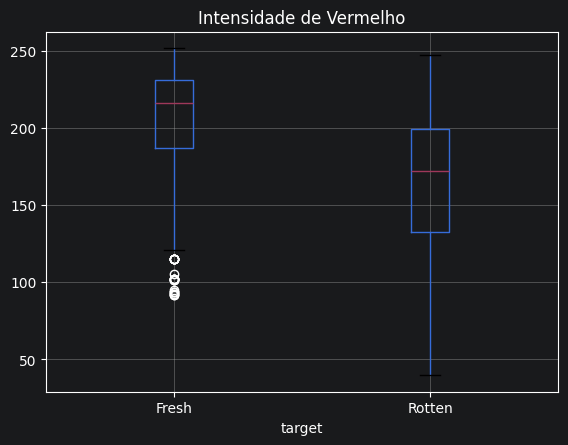

In [43]:
plt.figure(figsize=(8,5))

X_df["target"] = y

## intensidade red
X_df.boxplot(column="mean_r", by="target")

plt.title("Intensidade de Vermelho")

plt.suptitle("")

plt.show()

# 📈 | Histogramas

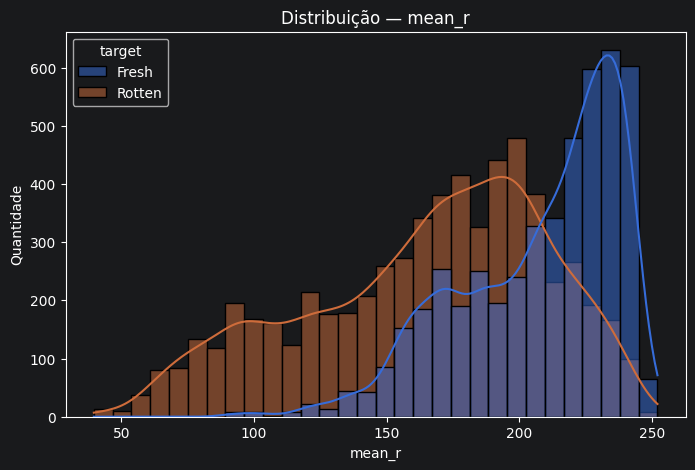

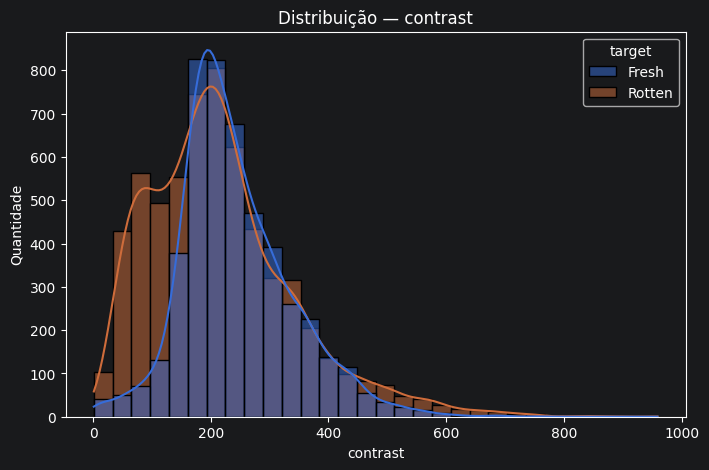

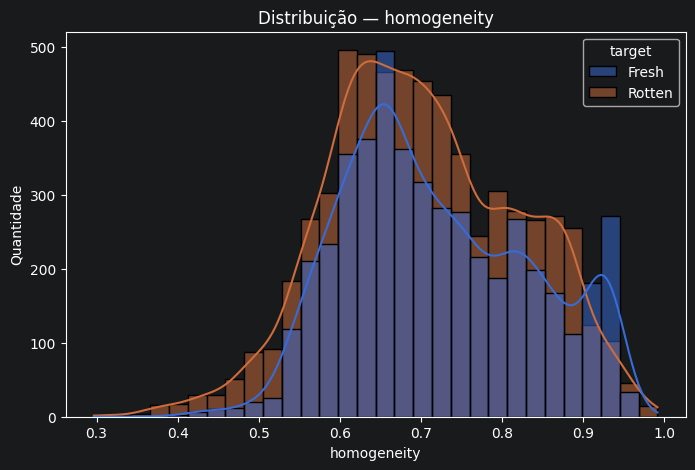

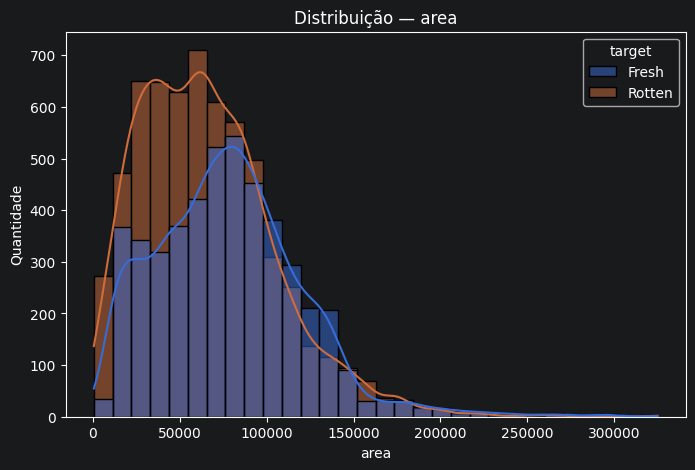

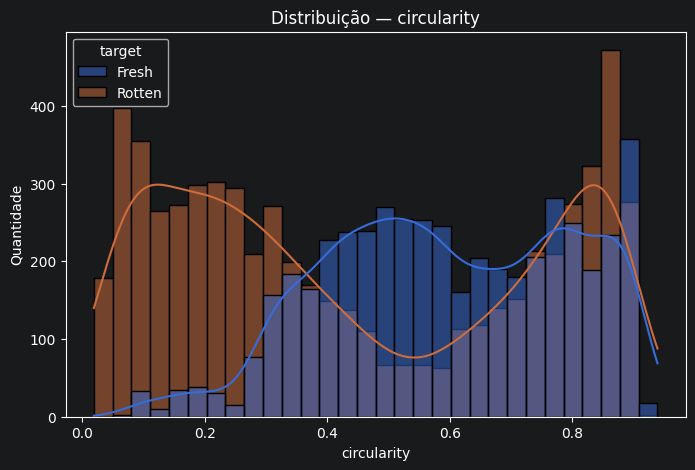

In [47]:
features_visualizar = [
    "mean_r",
    "contrast",
    "homogeneity",
    "area",
    "circularity"
]

for feature in features_visualizar:

    plt.figure(figsize=(8,5))

    sns.histplot(
        data=X_df,
        x=feature,
        hue="target",
        bins=30,
        kde=True
    )

    plt.title(
        f"Distribuição — {feature}"
    )

    plt.xlabel(feature)

    plt.ylabel("Quantidade")

    plt.show()

## Médias por Classe

In [45]:
X_df["target"] = y

medias = X_df.groupby("target").mean()

display(medias)

,area,perimeter,eccentricity,solidity,extent,circularity,hu1,hu2,hu3,hu4,...,mean_b,mean_g,mean_r,mean_h,mean_s,mean_v,contrast,homogeneity,energy,correlation
target,,,,,,,,,,,,,,,,,,,,,
Fresh,78138.445148,1311.130900,0.557552,0.893194,0.687718,0.596655,3.124967,7.773444,9.695869,9.834932,...,85.363608,156.213313,207.632009,30.124917,154.310112,211.728884,243.33708,0.719705,0.465679,0.979732
Rotten,65671.105989,1653.462042,0.586780,0.833124,0.632296,0.443399,3.055087,7.631727,9.684740,9.826030,...,80.336528,118.179384,164.581310,22.362256,128.458917,165.429429,216.32448,0.703223,0.552516,0.973279


## Total de frutas:

In [ ]:
print(y_df["target"].value_counts())

#### Análise das Features

Os boxplots e as médias por classe indicam que algumas características apresentam diferenças entre frutas frescas e frutas deterioradas. As features relacionadas à textura, especialmente contraste e homogeneidade, mostraram maior potencial de separação entre as classes, o que é coerente com as alterações visuais causadas pelo processo de deterioração.

As características de cor também apresentaram diferenças entre as classes, enquanto algumas features de forma mostraram menor variação. Esses resultados sugerem que textura e cor são informações relevantes para a classificação do estado das frutas.